In [1]:
%matplotlib widget
import ipywidgets as widgets
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [10]:
widgets.IntSlider(
    value=7,
    min=0,
    max=10,
    step=1,
    description='Test:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)



IntSlider(value=7, continuous_update=False, description='Test:', max=10)

In [11]:
import numpy as np
import matplotlib
matplotlib.use("TkAgg")  # <-- Change 1: proper interactive backend
import matplotlib.pyplot as plt

class DynamicalSystem:
    def __init__(self, A=0.9, B=1, C=1, D=0, dt=0.1):
        self.A = np.atleast_2d(A)
        self.B = np.atleast_2d(B)
        self.C = np.atleast_2d(C)
        self.D = np.atleast_2d(D)
        self.dt = dt

    def step(self, x, u):
        x = np.atleast_2d(x)
        u = np.atleast_2d(u)
        return self.A @ x + self.B @ u

    def output(self, x, u):
        x = np.atleast_2d(x)
        u = np.atleast_2d(u)
        y = self.C @ x + self.D @ u
        return y.item() if y.size == 1 else y

def live_plot(system, x0, u_seq, t_sim):
    plt.close('all')  # <-- Change 2: close old figures

    dt = system.dt
    x = np.atleast_2d(x0)

    # Data storage
    time_data = []
    output_data = []
    input_data = []

    window_size = int(5 / dt)  # <-- Change 3: show last 5 seconds

    plt.ion()
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    line_y, = ax[0].plot([], [], label='Output')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Output')

    line_u, = ax[1].plot([], [], label='Input', color='orange')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Input')
    plt.tight_layout()

    for t in np.arange(0, t_sim, dt):
        u = u_seq(t)
        x = system.step(x, u)
        y = system.output(x, u)

        time_data.append(t)
        output_data.append(y)
        input_data.append(u)

        # <-- Change 4: scroll using rolling window
        line_y.set_data(time_data[-window_size:], output_data[-window_size:])
        line_u.set_data(time_data[-window_size:], input_data[-window_size:])
        ax[0].set_xlim(max(0, t - 5), t)
        ax[1].set_xlim(max(0, t - 5), t)

        plt.pause(dt)

    plt.ioff()
    plt.show()

# Example usage
system = DynamicalSystem(A=0.9, B=1, C=1, D=0, dt=0.1)
live_plot(system, x0=0.0, u_seq=lambda t: np.sin(2 * np.pi * 0.5 * t), t_sim=10.0)


C:\Users\gertv\AppData\Local\Temp\ipykernel_23244\3876195109.py:3: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed in 3.10.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("TkAgg")  # <-- Change 1: proper interactive backend
C:\Users\gertv\AppData\Local\Temp\ipykernel_23244\3876195109.py:61: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[0].set_xlim(max(0, t - 5), t)
C:\Users\gertv\AppData\Local\Temp\ipykernel_23244\3876195109.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[1].set_xlim(max(0, t - 5), t)


In [4]:
class DynamicalSystem:
    def __init__(self, A = 0.9, B = 1, C = 1, D = 0, dt = 0.1):
        self.A = np.atleast_2d(A);
        self.B = np.atleast_2d(B);
        self.C = np.atleast_2d(C);
        self.D = np.atleast_2d(D);
        self.dt = dt;

    def step(self, x, u):
        x = np.atleast_2d(x);
        u = np.atleast_2d(u);
        return self.A @ x + self.B @ u
    
    def output(self, x, u):
        x = np.atleast_2d(x);
        u = np.atleast_2d(u);
        y = self.C @ x + self.D @ u
        return y.item() if y.size == 1 else y
    
    def simulate(self, x0, u_seq, t_sim):
        x = x0
        outputs = []
        dt = self.dt
        for t in np.arange(0, t_sim, dt):
            u = u_seq(t)
            x = self.step(x, u)
            y = self.output(x, u)
            outputs.append(y)
        return np.array(outputs)
    
def live_plot(system, x0, u_seq, t_sim):
    dt = system.dt
    x = np.atleast_2d(x0);

    # Initialize data storage for plotting
    time = []
    outputs = []
    inputs = []

    # Set up live plotting
    plt.ion()
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    line_y, = ax[0].plot(time, outputs, label='Output')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Output')

    line_u, = ax[1].plot(time, inputs, label='Input', color='orange')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Input')
    plt.tight_layout()

    for t in np.arange(0, t_sim, dt):
        u = u_seq(t)
        x = system.step(x, u)
        y = system.output(x, u)

        # Store data for plotting
        time.append(t)
        outputs.append(y)
        inputs.append(u)

        # Update live plot
        line_y.set_xdata(time)
        line_y.set_ydata(outputs)
        ax[0].relim()
        ax[0].autoscale_view()

        line_u.set_xdata(time)
        line_u.set_ydata(inputs)
        ax[1].relim()
        ax[1].autoscale_view() 
        fig.canvas.draw()        # <-- Force redraw
        fig.canvas.flush_events()    
    plt.ioff()
    plt.show()

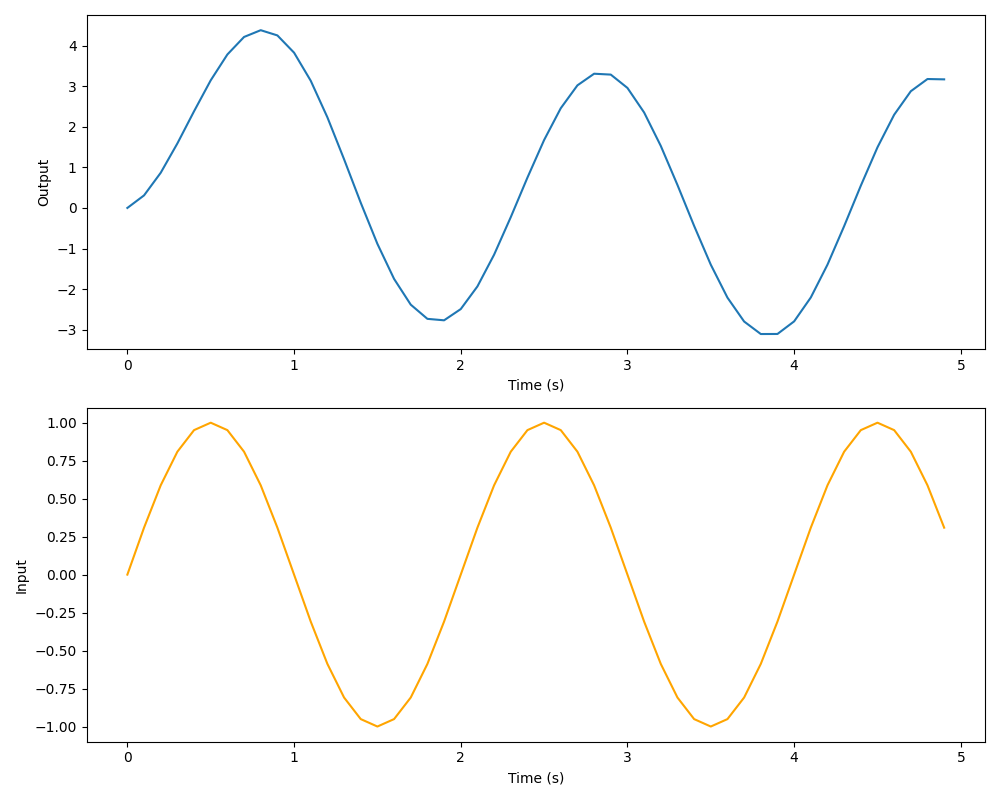

In [5]:
# Example usage
system = DynamicalSystem(A=0.9, B=1, C=1, D=0, dt=0.1)
live_plot(system, x0=0.0, u_seq=lambda t: np.sin(2 * np.pi * 0.5 * t), t_sim=5)